<a href="https://colab.research.google.com/github/norrismeg/odw/blob/main/Data_Challenge_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Challenge 4 (8 points) -- Advanced**

Use the data file challenge3.gwf with channels H1:CHALLENGE3 and L1:CHALLENGE3.

These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.

Any simulated signals have been added to both the H1 and L1 data

All simulated signals have spin = 0 and m1 = m2, with m1 somewhere in the range 10-50 solar masses
1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

2. Identify as many glitches as you can. Make a spectrogram of each one.

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
! pip install -q pycbc
! pip install -q gwpy
! pip install -U -q bilby==2.4.0 matplotlib==3.10.0 dynesty==2.1.5 corner==2.2.3 gwpy==3.0.12 lalsuite==7.25 scipy==1.12.0
# -- Click "restart runtime" in the runtime menu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [3]:
# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf

--2025-11-20 11:20:35--  https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 256814830 (245M)
Saving to: ‘challenge3.gwf’

challenge3.gwf      100%[===================>] 244.92M  39.5MB/s    in 6.2s    

2025-11-20 11:20:41 (39.5 MB/s) - ‘challenge3.gwf’ saved [256814830/256814830]



1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

H1
L1


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


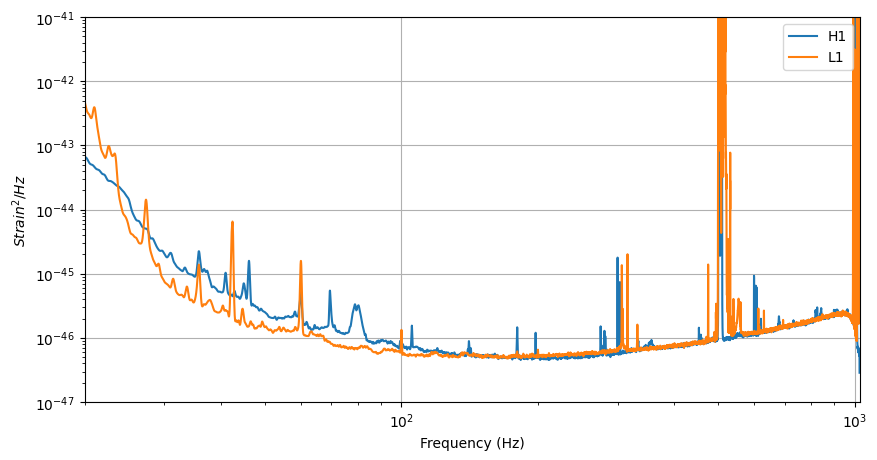

In [4]:
import matplotlib.pyplot as plt
from pycbc import frame
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation

ifos = ['H1','L1']
pycbc_strain = {}
data = {}
psd = {}

plt.figure(figsize=[10, 5])

# Read in and precondition the data
for ifo in ifos:
    channel = ifo+':CHALLENGE3'
    pycbc_strain[ifo] = frame.read_frame('challenge3.gwf', channel)

for ifo, ts in pycbc_strain.items():
    print(ifo)
    t_s = highpass(ts, 15)
    data[ifo] = resample_to_delta_t(t_s, 1.0/2048).crop(2, 2)

    # Estimate the power spectral density of the data
    p = data[ifo].psd(4)
    p = interpolate(p, data[ifo].delta_f)
    p = inverse_spectrum_truncation(p, int(4 * data[ifo].sample_rate), low_frequency_cutoff=15.0)
    psd[ifo] = p

    plt.plot(psd[ifo].sample_frequencies, psd[ifo], label=ifo)

plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-47, 1e-41)
plt.xlim(20, 1024)
plt.ylabel('$Strain^2 / Hz$')
plt.xlabel('Frequency (Hz)')
plt.grid()
plt.legend()
plt.show()

In [5]:
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from gwpy.timeseries import TimeSeries
from scipy.signal import find_peaks
from pycbc.vetoes import power_chisq
from pycbc.events.ranking import newsnr

m_range = [10,15,20,25,30,40,50]

snr = {}
chisq = {}

H1_trig = np.empty((0,3))
L1_trig = np.empty((0,3))

H1_trig_nsnr = np.empty((0,3))
L1_trig_nsnr = np.empty((0,3))

signals = [] # List of possible signals
glitches = [] # List of likely glitches

for mass in m_range:
  print(mass)
  hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                            mass1=mass,
                            mass2=mass,
                            delta_t=data['H1'].delta_t,
                            f_lower=20.0)
  hp.resize(len(data['H1'])) # why resize it to be the length of the data?
  hp = hp.cyclic_time_shift(hp.start_time) # what time is it being shifted to?

  for ifo in ifos:
    snr[ifo] = matched_filter(hp, data[ifo], psd=psd[ifo], low_frequency_cutoff=20.0)
    snr[ifo] = snr[ifo].crop(4 + 4, 4)

    # Remove time corrupted by the template filter and the psd filter
    # We remove 4 seconds at the beginning and end for the PSD filtering
    # And we remove 4 additional seconds at the beginning to account for
    # the template length (this is somewhat generous for
    # so short a template). A longer signal such as from a BNS, would
    # require much more padding at the beginning of the vector.

    #plt.figure(figsize=[10, 4])
    #plt.plot(snr[ifo].sample_times, abs(snr[ifo]), label=ifo+': '+str(mass))
    #plt.legend()
    #plt.ylim(0,30)
    #plt.grid(True)
    #plt.ylabel('Signal-to-noise')
    #plt.xlabel('Time (s)')
    #plt.show()

    snr_ts = snr[ifo]
    snr_peaks, _ = find_peaks(snr_ts, distance=2048, height=8)
    snr_trig = np.empty((0,3))
    for peak1 in snr_peaks:
      print(snr_ts.sample_times[peak1])
      trig_snr_try = np.array([[snr[ifo].sample_times[peak1], abs(snr_ts[peak1]), float(mass)]]) # [(time, snr, mass)]
      snr_trig = np.concatenate((snr_trig, trig_snr_try))

    # Add trigger time to list if not on the list already. Keep ifos separate for now
    if ifo == 'H1':
      H1_trig = np.concatenate((H1_trig, snr_trig))
    elif ifo == 'L1':
      L1_trig = np.concatenate((L1_trig, snr_trig))
    else: print('error')

  print('...')
  # From ODW Tutorial 2.3
  for ifo in ifos:
    # The number of bins to use. In principle, this choice is arbitrary. In practice,
    # this is empirically tuned.
    nbins = 26
    chisq[ifo] = power_chisq(hp, data[ifo], nbins, psd[ifo], low_frequency_cutoff=20.0)
    chisq[ifo] = chisq[ifo].crop(4 + 4, 4)

    dof = nbins * 2 - 2
    chisq[ifo] /= dof

    nsnr_dict = {ifo:newsnr(abs(snr[ifo]), chisq[ifo])}
    nsnr = TimeSeries(nsnr_dict[ifo], sample_rate = 2048)

    #plt.figure(figsize=[10, 4])
    #plt.plot(snr[ifo].sample_times, abs(nsnr), label=ifo+': '+str(mass))
    #plt.legend()
    #plt.title('New SNR')
    #plt.ylim(0,30)
    #plt.grid(True)
    #plt.ylabel('Signal-to-noise')
    #plt.xlabel('Time (s)')
    #plt.show()

    nsnr_peaks, _ = find_peaks(nsnr, distance=2048, height=8)
    #nsnr_trig = snr[ifo].sample_times[nsnr_peaks]
    nsnr_trig = np.empty((0,3))
    #print('nsnr_trig:',nsnr_trig)
    #print('NSNR Peaks:',nsnr_peaks)
    for peak in nsnr_peaks:
        #print(nsnr[peak])
        #print(snr[ifo].sample_times[peak])
        trig_nsnr_try = np.array([[snr[ifo].sample_times[peak], nsnr[peak], float(mass)]]) # [(time, nsnr, mass)]
        #print('trig_nsnr_try:',trig_nsnr_try)
        nsnr_trig = np.concatenate((nsnr_trig, trig_nsnr_try))

    # Add trigger time to list if not on the list already. Keep ifos separate for now
    if ifo == 'H1':
      H1_trig_nsnr = np.concatenate((H1_trig_nsnr, nsnr_trig))
    elif ifo == 'L1':
      L1_trig_nsnr = np.concatenate((L1_trig_nsnr, nsnr_trig))
    else: print('error')

  #print('H1 Potential Signals:')
  #print(H1_trig_nsnr)
  #print('L1 Potential Signals:')
  #print(L1_trig_nsnr)

print()
print('H1 Triggers:')
print(H1_trig)
print()
print('L1 Triggers:')
print(L1_trig)

print()
print()
print('H1 Potential Signals:')
print(H1_trig_nsnr)
print()
print('L1 Potential Signals:')
print(L1_trig_nsnr)

# Why are trigger times slightly different for each mass template? Which trigger time should I use for the next steps? How do I condense triggers list?
# Use time given by mass template with the highest SNR

# If SNR > threshold (10?) and signal occurs in both detectors within 15 ms using the same template, add time, snrp, and template mass to the list of signals
# If SNR > threshold (10?) and signal only occurs in one detector, add time, snrp, detector, and template mass to the list of glitches

# gwpy TimeSeries methods: correlate, find_gates, inject
# numpy.extract

10


/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:225: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = arr.astype(dtype)


1638.17919921875
2483.96728515625
2892.74853515625
1638.1796875
2483.96728515625
2892.77978515625
...
15
1638.15771484375
2892.7099609375
196.08447265625
1638.1572265625
2892.73828125
...
20
1638.154296875
2892.712890625
196.09765625
1638.154296875
2892.712890625
...
25
1638.15283203125
2892.705078125
196.08740234375
1638.15283203125
2892.705078125
...
30
987.68994140625
1638.150390625
2892.70263671875
196.08447265625
826.42529296875
1101.4248046875
1638.1416015625
2892.70263671875
...
40
987.66796875
1638.14501953125
2892.703125
3219.185546875
196.078125
1638.134765625
2892.70361328125
3219.185546875
...
50
987.6552734375
1101.41748046875
1638.142578125
2483.9384765625
2892.69482421875
196.07666015625
1101.41748046875
1638.14306640625
2892.69482421875
3219.17626953125
...

H1 Triggers:
[[1638.17919922    8.9421468    10.        ]
 [2483.96728516   28.87652003   10.        ]
 [2892.74853516    9.93726134   10.        ]
 [1638.15771484   18.52853847   15.        ]
 [2892.70996094   14.9

In [5]:
import numpy as np

#H1_trig_try = [[1638.17919922,    8.9421468,    10.        ],
 #[2483.96728516,   28.87652003,   10.        ],
 #[2892.74853516,    9.93726134,   10.        ],
 #[1638.15429688,   20.11870556,   20.        ],
 #[2892.71289062,   23.21612117,   20.        ],
 #[ 987.68994141,    8.12015318,   30.        ],
 #[1638.15039062,   17.81312802,   30.        ],
 #[2892.70263672,   19.61884165,   30.        ],
 #[ 987.66796875,    9.00574345,   40.        ],
 #[1638.14501953,   14.96389139,   40.        ],
 #[2892.703125,     23.43810638,   40.        ],
 #[3219.18554688,    9.86339277,   40.        ],
 #[ 987.65527344,   11.08943854,   50.        ],
 #[1101.41748047,    8.3733043,    50.        ],
 #[1638.14257812,   16.96622644,   50.        ],
 #[2483.93847656,    9.71857823,   50.        ],
 #[2892.69482422,   21.56881314,   50.        ]]

#H1_trig_try2 = np.array(H1_trig_try)

#print(H1_trig_try2)

H1_trig_sort = H1_trig[H1_trig[:,0].argsort()]
#print(H1_trig_sort)

#L1_trig_try = np.array([[1638.1796875,     8.28647499,   10.        ],
 #[2483.96728516,   33.51976913,   10.        ],
 #[2892.77978516,   10.42539554,   10.        ],
 #[ 196.09765625,    9.00428411,   20.        ],
 #[1638.15429688,   18.52827951,   20.        ],
 #[2892.71289062,   25.55262021,   20.        ],
 #[ 196.08447266,   11.75855297,   30.        ],
 #[ 826.42529297,    9.43795047,   30.        ],
 #[1101.42480469,   10.63215619,   30.        ],
 #[1638.14160156,   12.64955494,   30.        ],
 #[2892.70263672,   20.04952386,   30.        ],
 #[ 196.078125,     16.85773383,   40.        ],
 #[1638.13476562,   13.57115073,   40.        ],
 #[2892.70361328,   19.28844014,   40.        ],
 #[3219.18554688,    9.72879024,   40.        ],
 #[ 196.07666016,   15.82829612,   50.        ],
 #[1101.41748047,    9.33368314,   50.        ],
 #[1638.14306641,   15.14134965,   50.        ],
 #[2892.69482422,   24.25891352,   50.        ],
 #[3219.17626953,    9.59666047,   50.        ]])

L1_trig_sort = L1_trig[L1_trig[:,0].argsort()]
#print(L1_trig_sort)


#h1_signals_try = [[  27.2684302,  2483.96728516,   10.        ],
 #[   8.46005674,  826.43066406,   25.        ],
 #[   8.81624226, 1101.43066406,   25.        ],
 #[  11.18428347, 1101.42773438,   30.        ],
 #[   9.15108745, 3219.18798828,   30.        ],
 #[  12.25571057, 3219.18554688,   35.        ],
 #[  12.45424392, 3219.18359375,   40.        ],
 #[  11.97864226, 3219.18164062,   45.        ],
 #[  10.5153951,  3219.1796875,    50.        ]]

#H1_potential_try = np.array(h1_signals_try)

#l1_signals_try = [[  30.28455306, 2483.96728516,   10.        ],
 #[  10.00171522,  826.42724609,   30.        ],
 #[  10.47736398, 1101.42724609,   30.        ],
 #[  11.05291827, 3219.18554688,   35.        ],
 #[  14.10164208, 3219.18310547,   40.        ],
 #[  11.4192986,  3219.18066406,   45.        ],
 #[   9.46721198, 3219.17871094,   50.        ]]

#L1_potential_try = np.array(l1_signals_try)



#print(L1_potential_try)
#np.ndarray.sort(H1_potential_try)
#print(H1_potential_try[:, 1].argsort())
#print(H1_trig_nsnr[H1_trig_nsnr[:, 0].argsort()])
#print(L1_trig_nsnr[L1_trig_nsnr[:, 0].argsort()])

H1_trig_nsnr2 = np.array([[826.43066406, 8.46005674, 25.],[1101.42773438, 11.18428347, 30.],[2483.96728516, 27.2684302, 10.],[3219.18359375, 12.45424392, 40.]])
L1_trig_nsnr2 = np.array([[826.42724609, 10.00171522, 30.],[1101.42724609, 10.47736398, 30.],[2483.96728516, 30.28455306, 10.],[3219.18310547, 14.10164208, 40.]])
print("H1_trig_nsnr2:")
print(H1_trig_nsnr2)
print("\nL1_trig_nsnr2:")
print(L1_trig_nsnr2)

#print(H1_potential_try)
#H1_sort = np.take_along_axis(H1_potential_try, H1_potential_try[:, 1].argsort(), axis=0)
#print(H1_sort)

H1_trig2 = np.array([[987.65527344, 11.08943854, 50.],[1101.41748047, 8.3733043, 50.],[1638.15429688, 20.11870556, 20.],[2483.96728516, 28.87652003, 10.],[2892.70507812, 27.14743073, 25.],[3219.18554688, 9.86339277, 40.]])
L1_trig2 = np.array([[196.078125, 16.85773383, 40.],[826.42529297, 9.43795047, 30.],[1101.42480469, 10.63215619, 30.],[1638.15429688, 18.52827951, 20.],[2483.96728516, 33.51976913, 10.],[2892.71289062, 25.55262021, 20.],[3219.18554688, 9.72879024, 40.]])

print("\nH1_trig2:")
print(H1_trig2)
print("\nL1_trig2:")
print(L1_trig2)

signals = np.array([[826.42724609, 10.00171522, 30.],[1101.42724609, 10.47736398, 30.],[2483.96728516, 30.28455306, 10.],[3219.18310547, 14.10164208, 40.]])
glitches = np.array([[196.078125, 16.85773383, 40.],[987.65527344, 11.08943854, 50.],[1638.15429688, 20.11870556, 20.],[2892.70507812, 27.14743073, 25.]])

print("\nSignals:")
print(signals)
print("\nGlitches:")
print(glitches)


NameError: name 'H1_trig' is not defined

In [6]:
signals = np.array([[826.42724609, 10.00171522, 30.],[1101.42724609, 10.47736398, 30.],[2483.96728516, 30.28455306, 10.],[3219.18310547, 14.10164208, 40.]])
glitches = np.array([[196.078125, 16.85773383, 40.],[987.65527344, 11.08943854, 50.],[1638.15429688, 20.11870556, 20.],[2892.70507812, 27.14743073, 25.]])

print("\nSignals:")
print(signals)
print("\nGlitches:")
print(glitches)


Signals:
[[ 826.42724609   10.00171522   30.        ]
 [1101.42724609   10.47736398   30.        ]
 [2483.96728516   30.28455306   10.        ]
 [3219.18310547   14.10164208   40.        ]]

Glitches:
[[ 196.078125     16.85773383   40.        ]
 [ 987.65527344   11.08943854   50.        ]
 [1638.15429688   20.11870556   20.        ]
 [2892.70507812   27.14743073   25.        ]]


In [ ]:
mass = 10

hp2, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                            mass1=mass,
                            mass2=mass,
                            delta_t=data['H1'].delta_t,
                            f_lower=20.0)
hp2.resize(len(data['H1'])) # why resize it to be the length of the data?
hp2 = hp2.cyclic_time_shift(hp2.start_time) # what time is it being shifted to?

snr2 = {}
chisq2 = {}
for ifo in ifos:
  snr2[ifo] = matched_filter(hp2, data[ifo], psd=psd[ifo], low_frequency_cutoff=20.0)
  snr2[ifo] = snr2[ifo].crop(4 + 4, 4)

  plt.figure(figsize=[10, 4])
  plt.plot(snr2[ifo].sample_times, abs(snr2[ifo]), label=ifo+': '+str(mass))
  plt.legend()
  plt.ylim(0,30)
  plt.grid(True)
  plt.ylabel('Signal-to-noise')
  plt.xlabel('Time (s)')
  plt.show()

  snr_peaks2, _ = find_peaks(snr2[ifo], distance=2048, height=8)
  snr_trig2 = snr2[ifo].sample_times[snr_peaks2]
  print(snr_trig2)

for ifo in ifos:
  nbins = 26
  chisq2[ifo] = power_chisq(hp2, data[ifo], nbins, psd[ifo], low_frequency_cutoff=20.0)
  chisq2[ifo] = chisq2[ifo].crop(4 + 4, 4)

  dof = nbins * 2 - 2
  chisq2[ifo] /= dof

  nsnr_dict2 = {ifo:newsnr(abs(snr2[ifo]), chisq2[ifo])}
  nsnr2 = TimeSeries(nsnr_dict2[ifo], sample_rate = 2048)
  nsnr_peaks2, _ = find_peaks(nsnr2, distance=2048, height=8)
  for peak in nsnr_peaks2:
    print(nsnr[peak])

  plt.figure(figsize=[10, 4])
  plt.plot(snr[ifo].sample_times, abs(nsnr), label=ifo+': '+str(mass))
  plt.legend()
  plt.title('New SNR')
  plt.ylim(0,30)
  plt.grid(True)
  plt.ylabel('Signal-to-noise')
  plt.xlabel('Time (s)')
  plt.show()

In [16]:
from pycbc.detector import Detector

# Calculate the time of flight between each LIGO observatory
d = Detector("L1")
tof = d.light_travel_time_to_detector(Detector("H1"))
print(tof)

0.010012846152267725


In [ ]:
import numpy as np

arr_try2 = np.empty((0,3))
print(arr_try2)

arr_try = np.array([[25.6, 2841.624, 10.]]) # [(nsnr, time, mass)]
arr_try2 = np.concatenate((arr_try2, arr_try))

print('arr_try2:','\n',arr_try2)
print(arr_try2)

2. Identify as many glitches as you can. Make a spectrogram of each one.

In [ ]:
from gwpy.timeseries import TimeSeries,TimeSeriesDict
gwpy_strain = TimeSeriesDict.read('challenge3.gwf', ["H1:CHALLENGE3","L1:CHALLENGE3"])

print(gwpy_strain)

ifos2 = ['H1:CHALLENGE3','L1:CHALLENGE3']

#for ifo2,ts2 in gwpy_strain.items():
    #t_s2 = highpass(ts2, 15)
    #data2[ifo2] = resample_to_delta_t(t_s2, 1.0/2048).crop(2, 2)

In [ ]:
from gwpy import spectrogram

for ifo2 in ifos2:
    print(ifo2)
    specgram_data = gwpy_strain[ifo2]
    specgram = specgram_data.spectrogram(20, fftlength=4, overlap=2, window='hann') ** (1/2.)
    plot = specgram.plot(norm='log', vmin=5e-24, vmax=1e-20)
    ax = plot.gca()
    ax.set_title(ifo2)
    ax.set_epoch(0)
    ax.set_yscale('log')
    ax.set_ylim(10, 1400)
    ax.set_xlim(10,20)
    ax.colorbar(label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]",)
    plot.show()

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [9]:
import bilby
from gwpy.timeseries import TimeSeries

# Make bilby more terse
bilby.core.utils.log.setup_logger(log_level='WARNING')

merger_time = signals[3,0]

sampling_rate = 4096  # needs to be high enough for the signals found in steps above
duration = 4  # needs to be long enough for the signals found in steps above
start_time = merger_time-2  # needs to be set so that the segment defined by [start_time,start_time+duration] contains the signal

print(merger_time)

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

H1.set_strain_data_from_frame_file('challenge3.gwf', sampling_rate, duration, start_time=start_time, channel=f'H1:CHALLENGE3')
L1.set_strain_data_from_frame_file('challenge3.gwf', sampling_rate, duration, start_time=start_time, channel=f'L1:CHALLENGE3')


3219.18310547


In [42]:
print(H1)
print(L1)

Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/usr/local/lib/python3.12/dist-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05)
Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/usr/local/lib/python3.12/dist-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)


In [13]:
from bilby.core.prior import Uniform, PowerLaw
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters

chirp_mass_min = 10/(2**(1/5))
chirp_mass_max = 50/(2**(1/5))
print(chirp_mass_min,chirp_mass_max)

#merger_times = signals[:,0]
#print(merger_times)

psd_duration = duration * 32
psd_start_time = start_time - psd_duration
psd_end_time = psd_start_time + psd_duration

H1_psd_data = TimeSeries.read('challenge3.gwf', channel="H1:CHALLENGE3")
H1_psd_data = H1_psd_data.crop(psd_start_time, psd_end_time)
print(len(H1_psd_data)/(4096))
L1_psd_data = TimeSeries.read('challenge3.gwf', channel="L1:CHALLENGE3")
L1_psd_data = L1_psd_data.crop(psd_start_time, psd_end_time)
print(len(L1_psd_data)/(4096))
psd_alpha = 2 * H1.strain_data.roll_off / duration
H1_psd = H1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1_psd = L1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1_psd.frequencies.value, psd_array=L1_psd.value)

H1.maximum_frequency = 1024
L1.maximum_frequency = 1024

print('PSD Done')

prior = bilby.core.prior.PriorDict()
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=chirp_mass_min,maximum=chirp_mass_max)
prior['mass_ratio'] = 1.0
prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=merger_time-0.1, maximum=merger_time+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
prior['dec'] = Cosine(name='dec')
prior['ra'] = Uniform(name="ra", minimum=0, maximum=2*np.pi, boundary='periodic')
prior['theta_jn'] = Sine(name='theta_jn')
prior['psi'] = Uniform(name="psi", minimum=0, maximum=np.pi, boundary='periodic')
prior['luminosity_distance'] = PowerLaw(alpha=2, name='luminosity_distance', minimum=50, maximum=2000, unit='Mpc', latex_label='$d_L$')

print('Prior done')

# First, put our "data" created above into a list of interferometers (the order is arbitrary)
interferometers = [H1, L1]

# Next create a dictionary of arguments which we pass into the LALSimulation waveform - we specify the waveform approximant here
waveform_arguments = dict(
    waveform_approximant='SEOBNRv4_opt', reference_frequency=100., catch_waveform_errors=True)

# Next, create a waveform_generator object. This wraps up some of the jobs of converting between parameters etc
waveform_generator = bilby.gw.WaveformGenerator(
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments=waveform_arguments,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters)

# Finally, create our likelihood, passing in what is needed to get going
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers, waveform_generator, priors=prior,
    time_marginalization=True, phase_marginalization=True, distance_marginalization=True)

print('Likelihood done')

result_short = bilby.run_sampler(
    likelihood, prior, sampler='dynesty', outdir='short', label="signal_1",
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    nlive=250, dlogz=1.,  # <- Arguments are used to make things fast - not recommended for general use
    clean=True,
)

print('Run sampler done')

result_short.posterior

8.705505632961241 43.527528164806206
128.0
128.0
PSD Done
Prior done
Likelihood done


1it [00:00, ?it/s]

  0%|          | 0/377 [00:00<?, ?it/s]

  0%|          | 0/377 [00:00<?, ?it/s]

  0%|          | 0/377 [00:00<?, ?it/s]

  0%|          | 0/377 [00:00<?, ?it/s]

Run sampler done


,chirp_mass,time_jitter,mass_ratio,phase,geocent_time,a_1,a_2,tilt_1,tilt_2,phi_12,...,chi_2_in_plane,chi_p,cos_tilt_1,cos_tilt_2,redshift,comoving_distance,mass_1_source,mass_2_source,chirp_mass_source,total_mass_source
0,32.607015,-0.000205,1.0,2.269827,3219.201036,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.344118,1396.546819,27.866327,27.866327,24.259047,55.732654
1,37.929323,-0.000125,1.0,1.525780,3219.198387,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.360096,1455.172506,32.034031,32.034031,27.887244,64.068062
2,32.762757,0.000036,1.0,2.802709,3219.201041,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.334803,1362.118903,28.194809,28.194809,24.545007,56.389618
3,32.796745,0.000153,1.0,3.090893,3219.201129,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.352362,1426.863320,27.857611,27.857611,24.251459,55.715223
4,32.821524,0.000181,1.0,5.903070,3219.200584,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.320658,1309.480046,28.547905,28.547905,24.852395,57.095811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,35.045226,0.000139,1.0,3.645481,3219.199643,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.361402,1459.942418,29.569798,29.569798,25.742004,59.139595
373,35.071115,-0.000011,1.0,0.730639,3219.199989,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.349949,1418.007130,29.842699,29.842699,25.979578,59.685398
374,35.063463,-0.000066,1.0,0.517487,3219.199696,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.359314,1452.317089,29.630636,29.630636,25.794967,59.261273
375,35.005419,-0.000226,1.0,0.343187,3219.199634,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.343560,1394.489575,29.928456,29.928456,26.054234,59.856911


In [14]:
M1 = result_short.posterior["mass_1_source"].values
M2 = result_short.posterior['mass_2_source'].values

lower_bound = np.quantile(M1, 0.05)
upper_bound = np.quantile(M1, 0.95)
median = np.quantile(M1, 0.5)
print("M1 = {} with a 90% C.I = {} -> {}".format(median, lower_bound, upper_bound))

lower_bound = np.quantile(M2, 0.05)
upper_bound = np.quantile(M2, 0.95)
median = np.quantile(M2, 0.5)
print("M2 = {} with a 90% C.I = {} -> {}".format(median, lower_bound, upper_bound))

M1 = 29.915910065835078 with a 90% C.I = 28.643734852449093 -> 31.139069203690834
M2 = 29.915910065835078 with a 90% C.I = 28.643734852449093 -> 31.139069203690834


In [15]:
print('Merger at 826.427 s:')
print('M1 = 26.498509893009075 with a 90% C.I = 25.18290941293212 -> 27.590380904157232')
print('M2 = 26.498509893009075 with a 90% C.I = 25.18290941293212 -> 27.590380904157232')

print('\nMerger at 1101.427 s:')
print('M1 = 27.514977896765892 with a 90% C.I = 26.91060551480084 -> 28.060106721617025')
print('M2 = 27.514977896765892 with a 90% C.I = 26.91060551480084 -> 28.060106721617025')

print('\nMerger at 2483.967 s:')
print('M1 = 9.89431552339536 with a 90% C.I = 9.884177987520582 -> 9.90637152977974')
print('M2 = 9.89431552339536 with a 90% C.I = 9.884177987520582 -> 9.90637152977974')

print('\nMerger at 2892.705 s:')
print('M1 = 37.79648436212213 with a 90% C.I = 36.16878270499494 -> 39.399953533490944')
print('M2 = 37.79648436212213 with a 90% C.I = 36.16878270499494 -> 39.399953533490944')

Merger at 826.427 s:
M1 = 26.498509893009075 with a 90% C.I = 25.18290941293212 -> 27.590380904157232
M2 = 26.498509893009075 with a 90% C.I = 25.18290941293212 -> 27.590380904157232

Merger at 1101.427 s:
M1 = 27.514977896765892 with a 90% C.I = 26.91060551480084 -> 28.060106721617025
M2 = 27.514977896765892 with a 90% C.I = 26.91060551480084 -> 28.060106721617025

Merger at 2483.967 s:
M1 = 9.89431552339536 with a 90% C.I = 9.884177987520582 -> 9.90637152977974
M2 = 9.89431552339536 with a 90% C.I = 9.884177987520582 -> 9.90637152977974

Merger at 2892.705 s:
M1 = 37.79648436212213 with a 90% C.I = 36.16878270499494 -> 39.399953533490944
M2 = 37.79648436212213 with a 90% C.I = 36.16878270499494 -> 39.399953533490944
